In [4]:
import pandas as pd 
path= r"D:\مشروع1\Online Retail.xlsx"
df=pd.read_excel(path)

In [5]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [6]:
print(df.shape)
print(df.info())

(541909, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB
None


In [7]:
print(f'Null value no. : {df.isnull().sum()}')

print(f'\nDuplicated : {df.duplicated().sum()}')

print(f'\nQuantity Statistics : {df["Quantity"].describe()}')

print(f'\nUnitPrice Statistics : {df["UnitPrice"].describe()}')

print(f'\nUnique Countries : {df["Country"].nunique()}')

print(f'\nNegative Quantity : {(df["Quantity"] < 0).sum()}')

print(f'\nZero UnitPrice : {(df["UnitPrice"] == 0).sum()}')

Null value no. : InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Duplicated : 5268

Quantity Statistics : count    541909.000000
mean          9.552250
std         218.081158
min      -80995.000000
25%           1.000000
50%           3.000000
75%          10.000000
max       80995.000000
Name: Quantity, dtype: float64

UnitPrice Statistics : count    541909.000000
mean          4.611114
std          96.759853
min      -11062.060000
25%           1.250000
50%           2.080000
75%           4.130000
max       38970.000000
Name: UnitPrice, dtype: float64

Unique Countries : 38

Negative Quantity : 10624

Zero UnitPrice : 2515


In [8]:
df[df["Quantity"] < 0][["InvoiceNo", "StockCode", "Description", "Quantity", "UnitPrice"]].head(10)

,InvoiceNo,StockCode,Description,Quantity,UnitPrice
141,C536379,D,Discount,-1,27.50
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,4.65
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,1.65
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,0.29
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,0.29
238,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,0.29
239,C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,3.45
240,C536391,22557,PLASTERS IN TIN VINTAGE PAISLEY,-12,1.65
241,C536391,22553,PLASTERS IN TIN SKULLS,-24,1.65
939,C536506,22960,JAM MAKING SET WITH JARS,-6,4.25


In [9]:
print("Negative quantity invoices starting with C:")
print(df[df["Quantity"] < 0]["InvoiceNo"].astype(str).str.startswith("C").sum())

print("Negative quantity invoices NOT starting with C:")
print((~df[df["Quantity"] < 0]["InvoiceNo"].astype(str).str.startswith("C")).sum())

Negative quantity invoices starting with C:
9288
Negative quantity invoices NOT starting with C:
1336


In [10]:
negative_not_c = df[(df["Quantity"] < 0) &(~df["InvoiceNo"].astype(str).str.startswith("C"))]

print(negative_not_c[["InvoiceNo", "StockCode", "Description", "Quantity", "UnitPrice", "CustomerID"]].head(15))

     InvoiceNo StockCode Description  Quantity  UnitPrice  CustomerID
2406    536589     21777         NaN       -10        0.0         NaN
4347    536764    84952C         NaN       -38        0.0         NaN
7188    536996     22712         NaN       -20        0.0         NaN
7189    536997     22028         NaN       -20        0.0         NaN
7190    536998     85067         NaN        -6        0.0         NaN
7192    537000     21414         NaN       -22        0.0         NaN
7193    537001     21653         NaN        -6        0.0         NaN
7195    537003     85126         NaN        -2        0.0         NaN
7196    537004     21814         NaN       -30        0.0         NaN
7197    537005     21692         NaN       -70        0.0         NaN
7198    537006     21648         NaN      -130        0.0         NaN
7199    537007     21172         NaN       -80        0.0         NaN
7200    537008     21161         NaN      -120        0.0         NaN
7201    537009    84

In [11]:
print(negative_not_c["InvoiceNo"].nunique())
print(negative_not_c["StockCode"].nunique())

1336
1082


In [12]:
negative_not_c["Description"].value_counts().head(20)

Description
check                     120
damages                    45
damaged                    42
?                          41
sold as set on dotcom      20
Damaged                    14
thrown away                 9
Unsaleable, destroyed.      9
??                          7
wet damaged                 5
damages?                    5
ebay                        5
smashed                     4
missing                     3
wet pallet                  3
CHECK                       3
sold as 1                   2
incorrect stock entry.      2
crushed                     2
adjustment                  2
Name: count, dtype: int64

In [13]:
negative_not_c[["InvoiceNo", "Description", "Quantity", "UnitPrice", "Country"]].head(15)

,InvoiceNo,Description,Quantity,UnitPrice,Country
2406,536589,NaN,-10,0.0,United Kingdom
4347,536764,NaN,-38,0.0,United Kingdom
7188,536996,NaN,-20,0.0,United Kingdom
7189,536997,NaN,-20,0.0,United Kingdom
7190,536998,NaN,-6,0.0,United Kingdom
7192,537000,NaN,-22,0.0,United Kingdom
7193,537001,NaN,-6,0.0,United Kingdom
7195,537003,NaN,-2,0.0,United Kingdom
7196,537004,NaN,-30,0.0,United Kingdom
7197,537005,NaN,-70,0.0,United Kingdom


In [14]:
df[df.duplicated(keep=False)].sort_values(by=["InvoiceNo", "StockCode"]).head(15)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
565,536412,21448,12 DAISY PEGS IN WOOD BOX,2,2010-12-01 11:49:00,1.65,17920.0,United Kingdom
578,536412,21448,12 DAISY PEGS IN WOOD BOX,1,2010-12-01 11:49:00,1.65,17920.0,United Kingdom


In [15]:
df_clean = df.copy()

df_clean = df_clean.drop_duplicates()

print("Original:", df.shape)
print("After removing duplicates:", df_clean.shape)

Original: (541909, 8)
After removing duplicates: (536641, 8)


In [16]:
df_clean[df_clean["Description"].isnull()].head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
1988,536550,85044,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
2024,536552,20950,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
2025,536553,37461,NaN,3,2010-12-01 14:35:00,0.0,NaN,United Kingdom
2026,536554,84670,NaN,23,2010-12-01 14:35:00,0.0,NaN,United Kingdom
2406,536589,21777,NaN,-10,2010-12-01 16:50:00,0.0,NaN,United Kingdom


In [17]:
df_clean = df_clean.dropna(subset=["Description"])

print(df_clean.shape)

(535187, 8)


In [18]:
print(df_clean.isnull().sum())

InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     133583
Country             0
dtype: int64


In [19]:
df_clean[df_clean["UnitPrice"] == 0][["InvoiceNo", "StockCode", "Description", "Quantity", "CustomerID", "Country"]].head(15)

,InvoiceNo,StockCode,Description,Quantity,CustomerID,Country
6391,536941,22734,amazon,20,NaN,United Kingdom
6392,536942,22139,amazon,15,NaN,United Kingdom
7313,537032,21275,?,-30,NaN,United Kingdom
9302,537197,22841,ROUND CAKE TIN VINTAGE GREEN,1,12647.0,Germany
13217,537425,84968F,check,-20,NaN,United Kingdom
13218,537426,84968E,check,-35,NaN,United Kingdom
13264,537432,35833G,damages,-43,NaN,United Kingdom
14335,537534,85064,CREAM SWEETHEART LETTER RACK,1,NaN,United Kingdom
14336,537534,84832,ZINC WILLIE WINKIE CANDLE STICK,1,NaN,United Kingdom
14337,537534,84692,BOX OF 24 COCKTAIL PARASOLS,2,NaN,United Kingdom


In [20]:
df_clean["UnitPrice"].describe()

count    535187.000000
mean          4.645242
std          97.364810
min      -11062.060000
25%           1.250000
50%           2.080000
75%           4.130000
max       38970.000000
Name: UnitPrice, dtype: float64

In [21]:
print("UnitPrice = 0:", (df_clean["UnitPrice"] == 0).sum())
print("UnitPrice < 0:", (df_clean["UnitPrice"] < 0).sum())
print("Quantity < 0:", (df_clean["Quantity"] < 0).sum())

UnitPrice = 0: 1056
UnitPrice < 0: 2
Quantity < 0: 9725


In [35]:
df_clean = df_clean.dropna(subset=["CustomerID"]).copy()

df_sales = df_clean[(df_clean["Quantity"] > 0) &(df_clean["UnitPrice"] > 0)].copy()

In [36]:
df_sales["TotalPrice"] = df_sales["Quantity"] * df_sales["UnitPrice"]

In [37]:
print(df_sales.head())
print(df_sales.shape)

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  TotalPrice  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom       15.30  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom       20.34  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom       22.00  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom       20.34  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom       20.34  
(392692, 9)


In [38]:
print(df_sales.isnull().sum())
print(df_sales.describe())

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
TotalPrice     0
dtype: int64
            Quantity                    InvoiceDate      UnitPrice  \
count  392692.000000                         392692  392692.000000   
mean       13.119702  2011-07-10 19:13:07.771892480       3.125914   
min         1.000000            2010-12-01 08:26:00       0.001000   
25%         2.000000            2011-04-07 11:12:00       1.250000   
50%         6.000000            2011-07-31 12:02:00       1.950000   
75%        12.000000            2011-10-20 12:53:00       3.750000   
max     80995.000000            2011-12-09 12:50:00    8142.750000   
std       180.492832                            NaN      22.241836   

          CustomerID     TotalPrice  
count  392692.000000  392692.000000  
mean    15287.843865      22.631500  
min     12346.000000       0.001000  
25%     13955.000000       4.950000  
50%     15150

In [39]:
df_sales.to_csv(r"D:\مشروع1\Online_Retail_Clean.csv", index=False)

In [40]:
df_sales

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60


In [41]:
from datetime import timedelta 
snapshot_date = df_sales["InvoiceDate"].max() + timedelta(days=1)

rfm = df_sales.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (snapshot_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("TotalPrice", "sum")).reset_index()

print(rfm.head())
print(rfm.shape)

   CustomerID  Recency  Frequency  Monetary
0     12346.0      326          1  77183.60
1     12347.0        2          7   4310.00
2     12348.0       75          4   1797.24
3     12349.0       19          1   1757.55
4     12350.0      310          1    334.40
(4338, 4)


In [42]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[["Recency", "Frequency", "Monetary"]])

kmeans = KMeans( n_clusters=2, random_state=42, n_init=10)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

print("Cluster Distribution:")
print(rfm["Cluster"].value_counts())

print("\nAverage RFM per Cluster:")
print(rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean())


Cluster Distribution:
Cluster
0    4312
1      26
Name: count, dtype: int64

Average RFM per Cluster:
           Recency  Frequency      Monetary
Cluster                                    
0        93.057978   3.897263   1543.536842
1         6.038462  66.423077  85826.078077


In [43]:
CHURN_THRESHOLD_DAYS = 90
rfm["Churned"] = (rfm["Recency"] > CHURN_THRESHOLD_DAYS).astype(int)

print(rfm["Churned"].value_counts())

Churned
0    2889
1    1449
Name: count, dtype: int64


In [44]:
from sklearn.model_selection import train_test_split

X = rfm[["Frequency", "Monetary"]]

y = rfm["Churned"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (3470, 2)
X_test: (868, 2)
y_train: (3470,)
y_test: (868,)


In [45]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    "Naive Bayes": GaussianNB(),

    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42),

    "AdaBoost": AdaBoostClassifier( n_estimators=150, learning_rate=0.5, random_state=42),

    "Gradient Boosting": GradientBoostingClassifier( n_estimators=150, learning_rate=0.1, max_depth=3, random_state=42),

    "XGBoost": XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1, eval_metric="logloss", random_state=42) 
}
results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    results.append({
        "Model": name,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1 Score": round(f1, 4)
        })

    print(
        f"{name} → "
        f"Accuracy: {acc:.4f} | "
        f"Precision: {prec:.4f} | "
        f"Recall: {rec:.4f} | "
        f"F1: {f1:.4f}"
    )

Naive Bayes → Accuracy: 0.5230 | Precision: 0.4101 | Recall: 0.9759 | F1: 0.5776
Random Forest → Accuracy: 0.7143 | Precision: 0.5875 | Recall: 0.4862 | F1: 0.5321


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


AdaBoost → Accuracy: 0.7350 | Precision: 0.6103 | Recall: 0.5724 | F1: 0.5907
Gradient Boosting → Accuracy: 0.7051 | Precision: 0.5787 | Recall: 0.4310 | F1: 0.4941
XGBoost → Accuracy: 0.7005 | Precision: 0.5636 | Recall: 0.4586 | F1: 0.5057


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


[[472 106]
 [124 166]]


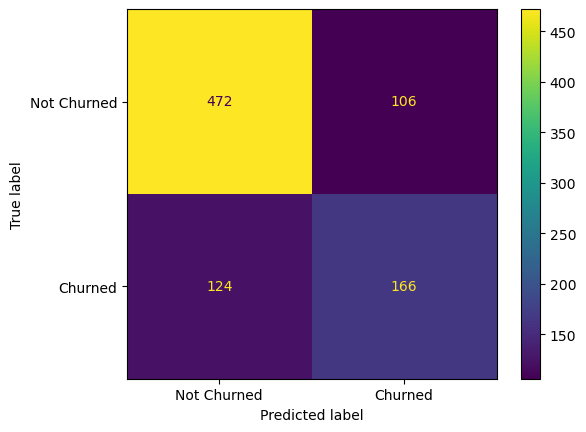

In [46]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

model = models["AdaBoost"]

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Churned", "Churned"])

disp.plot()
plt.show()